In [1]:
import os
os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = r"C:\Users\Nikhil Bidkar\retail-analytics\bigquery_key.json"

from google.cloud import bigquery
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

client = bigquery.Client(project="retail-analytics-493018")
print("Connected to BigQuery!")

Connected to BigQuery!


In [2]:
# Load all tables
orders = client.query("SELECT * FROM `retail-analytics-493018.olist_raw.orders`").to_dataframe()
customers = client.query("SELECT * FROM `retail-analytics-493018.olist_raw.customers`").to_dataframe()
order_items = client.query("SELECT * FROM `retail-analytics-493018.olist_raw.order_items`").to_dataframe()
payments = client.query("SELECT * FROM `retail-analytics-493018.olist_raw.payments`").to_dataframe()
reviews = client.query("SELECT * FROM `retail-analytics-493018.olist_raw.reviews`").to_dataframe()
products = client.query("SELECT * FROM `retail-analytics-493018.olist_raw.products`").to_dataframe()
sellers = client.query("SELECT * FROM `retail-analytics-493018.olist_raw.sellers`").to_dataframe()

print("All tables loaded!")
print(f"Orders: {orders.shape}")
print(f"Customers: {customers.shape}")
print(f"Order Items: {order_items.shape}")
print(f"Payments: {payments.shape}")
print(f"Reviews: {reviews.shape}")
print(f"Products: {products.shape}")
print(f"Sellers: {sellers.shape}")

C:\Users\Nikhil Bidkar\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\google\cloud\bigquery\table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


All tables loaded!
Orders: (99441, 8)
Customers: (99441, 5)
Order Items: (112650, 7)
Payments: (103886, 5)
Reviews: (99224, 7)
Products: (32951, 9)
Sellers: (3095, 4)


In [3]:
# Basic overview of orders table
print("=== ORDERS ===")
print(orders.dtypes)
print("\nNull values:")
print(orders.isnull().sum())

=== ORDERS ===
order_id                                      object
customer_id                                   object
order_status                                  object
order_purchase_timestamp         datetime64[us, UTC]
order_approved_at                datetime64[us, UTC]
order_delivered_carrier_date     datetime64[us, UTC]
order_delivered_customer_date    datetime64[us, UTC]
order_estimated_delivery_date    datetime64[us, UTC]
dtype: object

Null values:
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64


=== ORDER STATUS BREAKDOWN ===
order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64


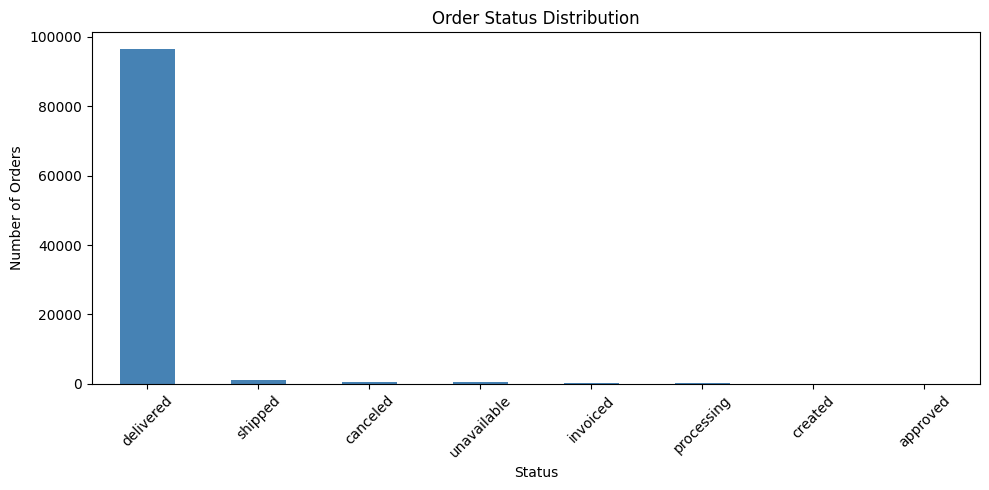

In [4]:
# What order statuses exist and how many?
print("=== ORDER STATUS BREAKDOWN ===")
print(orders['order_status'].value_counts())

# Visualize it
plt.figure(figsize=(10, 5))
orders['order_status'].value_counts().plot(kind='bar', color='steelblue')
plt.title('Order Status Distribution')
plt.xlabel('Status')
plt.ylabel('Number of Orders')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [5]:
top_products = order_items['product_id'].value_counts().head(10)
print(top_products)

product_id
aca2eb7d00ea1a7b8ebd4e68314663af    527
99a4788cb24856965c36a24e339b6058    488
422879e10f46682990de24d770e7f83d    484
389d119b48cf3043d311335e499d9c6b    392
368c6c730842d78016ad823897a372db    388
53759a2ecddad2bb87a079a1f1519f73    373
d1c427060a0f73f6b889a5c7c61f2ac4    343
53b36df67ebb7c41585e8d54d6772e08    323
154e7e31ebfa092203795c972e5804a6    281
3dd2a17168ec895c781a9191c1e95ad7    274
Name: count, dtype: int64


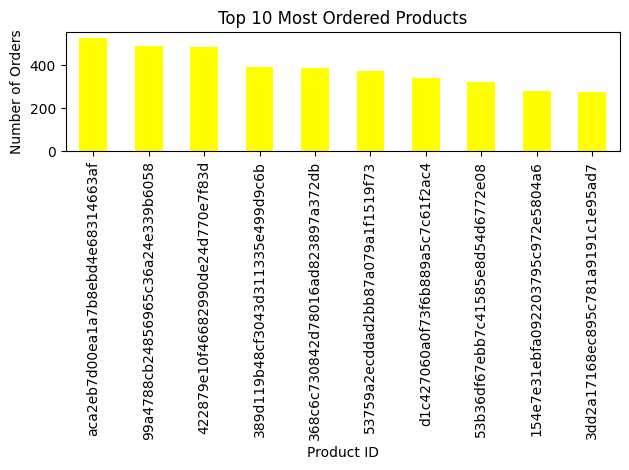

In [6]:
top_products.plot(kind='bar', color='yellow')
plt.xlabel('Product ID')
plt.ylabel('Number of Orders')
plt.title('Top 10 Most Ordered Products')
plt.tight_layout()
plt.show()

In [7]:
items_with_category = order_items.merge(products, on='product_id')
top_categories = items_with_category['product_category_name'].value_counts().head(10)
print(top_categories)

product_category_name
cama_mesa_banho           11115
beleza_saude               9670
esporte_lazer              8641
moveis_decoracao           8334
informatica_acessorios     7827
utilidades_domesticas      6964
relogios_presentes         5991
telefonia                  4545
ferramentas_jardim         4347
automotivo                 4235
Name: count, dtype: int64


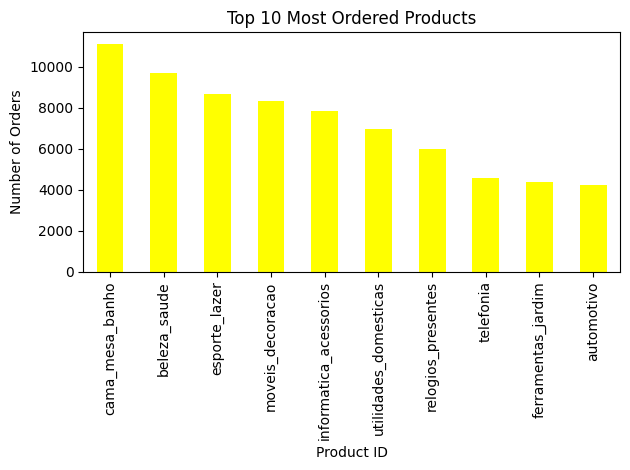

In [8]:
top_categories.plot(kind='bar', color='yellow')
plt.xlabel('Product ID')
plt.ylabel('Number of Orders')
plt.title('Top 10 Most Ordered Products')
plt.tight_layout()
plt.show()